In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import kagglehub

In [ ]:
kagglehub.dataset_download('shivam2503/diamonds', output_dir='./data')

In [4]:
df = pd.read_csv(r'data\diamonds.csv')
df.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [5]:
df.shape

(53940, 11)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  str    
 3   color       53940 non-null  str    
 4   clarity     53940 non-null  str    
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(6), int64(2), str(3)
memory usage: 4.5 MB


Cat col: cut, color, clarity

Num col: price, carat, depth, table, x, y, z

In [7]:
df.isnull().sum()

Unnamed: 0    0
carat         0
cut           0
color         0
clarity       0
depth         0
table         0
price         0
x             0
y             0
z             0
dtype: int64

In [8]:
df.columns

Index(['Unnamed: 0', 'carat', 'cut', 'color', 'clarity', 'depth', 'table',
       'price', 'x', 'y', 'z'],
      dtype='str')

In [9]:
df.describe()

,Unnamed: 0,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,26970.500000,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,15571.281097,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,1.000000,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,13485.750000,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,26970.500000,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,40455.250000,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,53940.000000,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


Text(0.5, 1.0, 'Correlation Matrix of Diamond Dataset')

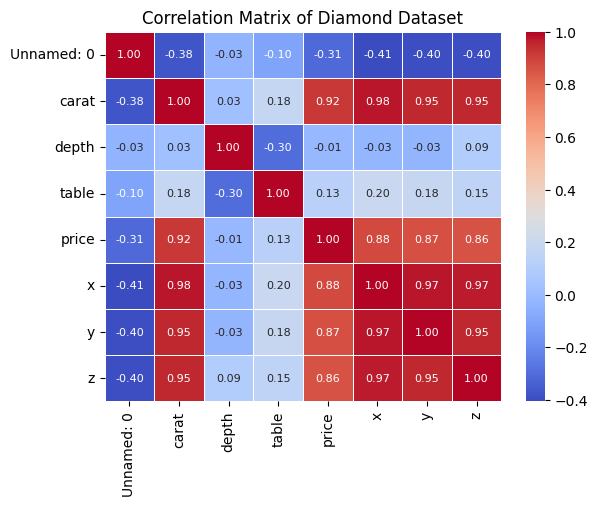

In [10]:
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, annot_kws={"size": 8})
plt.title('Correlation Matrix of Diamond Dataset')

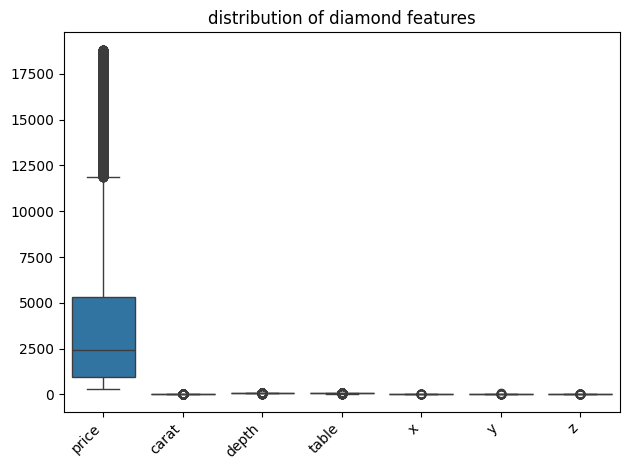

In [11]:
features = ['price', 'carat', 'depth', 'table', 'x', 'y', 'z']
sns.boxplot(data=df[features])
plt.xticks(rotation=45, ha='right')
plt.title('distribution of diamond features')
plt.tight_layout()

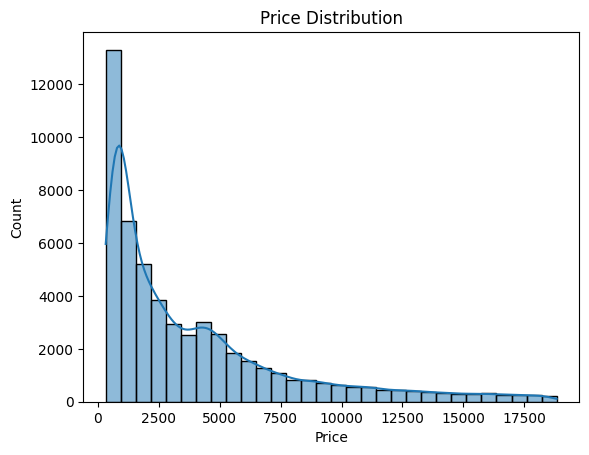

In [15]:
# shows how price is distributed across the dataset
sns.histplot(df['price'], bins=30, kde=True)
plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Count')
plt.show()

C:\Users\aashu\AppData\Local\Temp\ipykernel_5708\1416407636.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Colors: Cut')


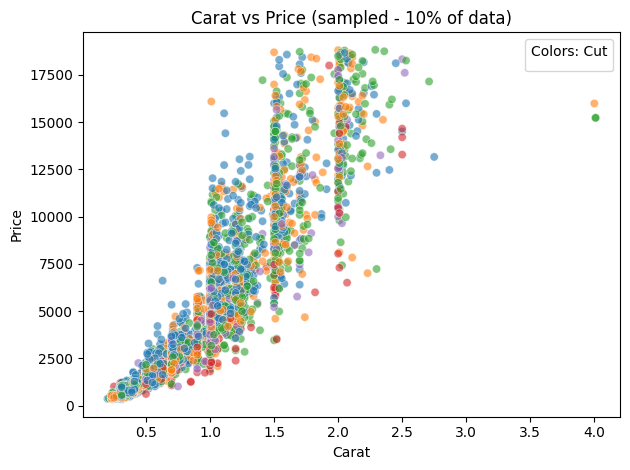

In [17]:
# Danceability vs popularity scatter (sampled for performance/readability)
sns.scatterplot(data=df.sample(5000, random_state=42), x='carat', y='price', hue='cut', alpha=0.6, legend=False)
plt.title('Carat vs Price (sampled - 10% of data)')
plt.xlabel('Carat')
plt.ylabel('Price')
plt.legend(title='Colors: Cut')
plt.tight_layout()
plt.show()

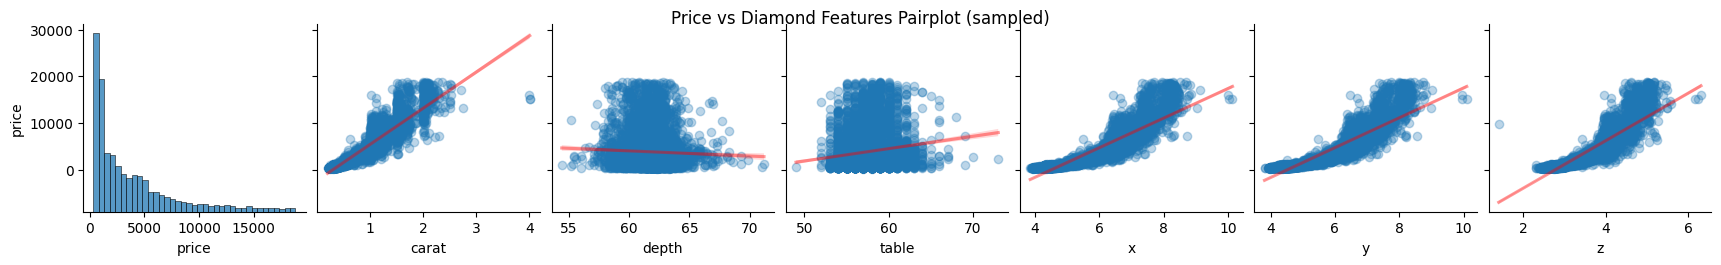

In [16]:
# Pairplot of price vs each diamond feature only
pair_features = ['price', 'carat', 'depth', 'table', 'x', 'y', 'z']

# pairplot on sample (10% of data)
sample_df = df[pair_features].sample(5000, random_state=42)

sns.pairplot(sample_df, x_vars=pair_features, y_vars=['price'], kind='reg', plot_kws={'line_kws':{'color':'red','alpha':0.4}, 'scatter_kws':{'alpha':0.3}})
plt.suptitle('Price vs Diamond Features Pairplot (sampled)', y=1.02)
plt.show()

# Now Look at Cat Features

In [18]:
# value_counts for cut, color, clarity
print("Cut Value Counts:")
print(df['cut'].value_counts())
print("\nColor Value Counts:")
print(df['color'].value_counts())
print("\nClarity Value Counts:")
print(df['clarity'].value_counts())

Cut Value Counts:
cut
Ideal        21551
Premium      13791
Very Good    12082
Good          4906
Fair          1610
Name: count, dtype: int64

Color Value Counts:
color
G    11292
E     9797
F     9542
H     8304
D     6775
I     5422
J     2808
Name: count, dtype: int64

Clarity Value Counts:
clarity
SI1     13065
VS2     12258
SI2      9194
VS1      8171
VVS2     5066
VVS1     3655
IF       1790
I1        741
Name: count, dtype: int64


Text(0, 0.5, 'Count')

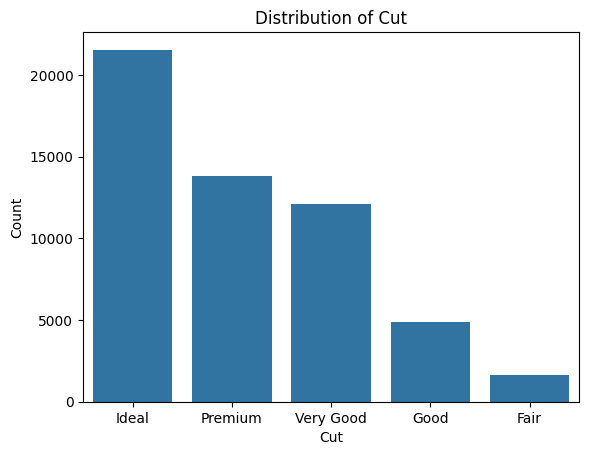

In [19]:
sns.countplot(data=df, x='cut', order=df['cut'].value_counts().index)
plt.title('Distribution of Cut')
plt.xlabel('Cut')
plt.ylabel('Count')


Best cut: Ideal > Premium > Good > Very Good > Fair

Text(0, 0.5, 'Count')

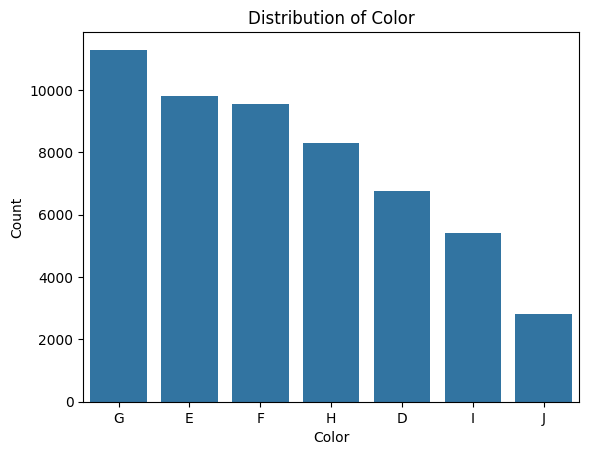

In [20]:
sns.countplot(data=df, x='color', order=df['color'].value_counts().index)
plt.title('Distribution of Color')
plt.xlabel('Color')
plt.ylabel('Count')

Best color: D > E > F > G > H > I > J

Text(0, 0.5, 'Count')

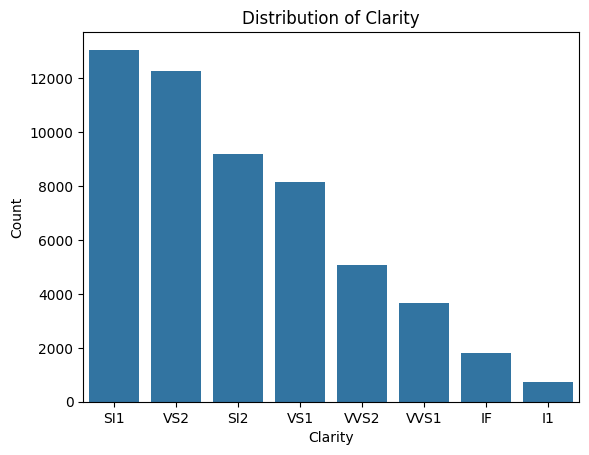

In [21]:
sns.countplot(data=df, x='clarity', order=df['clarity'].value_counts().index)
plt.title('Distribution of Clarity')
plt.xlabel('Clarity')
plt.ylabel('Count')

Best clarity: IF > VVS2 > VVS1 > VS2 > VS1 > SI2 > SI1